# Tarea Semanal 4: Primeros pasitos en la estimación espectral
**Autor:** Marco Trabattoni  
**Cátedra:** Procesamiento Digital de Señales - R6051  
**Docente:** Mariano Llamedo Soria
 
---
## 1. Introducción

En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.

Luego, haremos el siguiente experimento:

* frecuencia $f_0$ arbitraria, por ejemplo $f_0 = k_0 * f_s / N = k_0 . \Delta_f$,
* **Potencia normalizada**, es decir energía (o varianza) unitaria.

Se pide:

a) Sea $k_0 = \{N/4, N/4 + 0.25, N/4 + 0.5\}$. Notar que a cada senoidal se le agrega una pequeña desintonía respecto a $\Delta_f$. Graficar las tres densidades espectrales de potencia (PSD's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD. En base a la teoría estudiada, ¿cuál es la razón por la cual una señal senoidal tiene un espectro (PSD) tan diferente respecto a otra de muy pocos Hertz de diferencia?

### **Bonus:**

💎 Repetir el experimento mediante la técnica de *zero padding*. Dicha técnica consiste en agregar ceros al final de la señal para aumentar $\Delta_f$ de forma ficticia. Probar agregando un vector de $9*N$ ceros al final. Discuta los resultados obtenidos.


## Fundamento Conceptual

Para comprender el fenómeno de *spectral leakage*, vamos a analizar matemáticamente qué ocurre cuando digitalizamos una señal. Adquirir un registro finito de $N$ muestras en el tiempo equivale a multiplicar una señal senoidal de duración infinita por una **Ventana Rectangular** de base $T_d = N \cdot T_s$.

Una multiplicación en el dominio del tiempo se traduce en una **convolución** en el dominio de la frecuencia. La transformada de una senoidal pura es un par de deltas de Dirac, mientras que la transformada de una ventana rectangular es una función continua de tipo **Sinc**. Por lo tanto, el espectro continuo de nuestra señal truncada es una Sinc centrada en la frecuencia fundamental $f_0$, rodeada de lóbulos secundarios que decaen lentamente.

## Lo que se espera observar

La DFT estándar no es más que un muestreo discreto de ese espectro continuo, evaluado cada un diferencial de frecuencia $\Delta f = f_s / N$. En esta simulación, fijamos $f_s = 1000\text{ Hz}$ y $N = 1000$, obteniendo una resolución de $\Delta f = 1\text{ Hz}$. Evaluaremos los siguientes escenarios:

* **Caso Sincrónico ($\Delta = 0$):** Al valer $f_0 = 250\text{ Hz}$, la frecuencia coincide exactamente con el centro del bin 250. Se anticipa que los ceros de la función Sinc coincidan simétricamente con todos los demás bins de la DFT, ocultando los lóbulos secundarios y mostrando una delta limpia.
* **Caso Asincrónico ($\Delta = 0.25$ y $\Delta = 0.5$):** Al desintonizar la señal, los bins de la DFT muestrearán los lóbulos secundarios y las pendientes de la Sinc. Se espera visualizar una pérdida de amplitud en el pico principal (*Picket-Fence Effect*) y una sobreelevación de amplitudes espurias a los costados, deformando la visualización del espectro.


## 2. Configuración
En esta sección se importan las librerías necesarias (`numPy` y `matplotlib.pyplot`) y se definen tanto los algoritmos de trabajo, como los parámetros globales de la simulación (frecuencia de muestreo, Resolución espectral, etc).

In [1]:
# Importación de módulos que utilizaremos en esta tarea semanal 4:
import numpy as np
import matplotlib.pyplot as plt

#%%  Definicion de mi señal senoidal

def MT_Senoidal(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=100):
    
    """
    Genera una señal senoidal con los siguientes argumentos:
        
    vmax -- Amplitud máxima (Volts)
    dc   -- Valor medio (Volts)
    ff   -- Frecuencia de la senoidal (Hz)
    ph   -- Fase (Radianes)
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo (Hz)
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    
    # Calculamos el intervalo entre muestras (periodo de muestreo)
    ts = 1/fs
    
    # Generamos el vector de tiempo tt
    tt = np.arange(0.0, N*ts, ts)
    
    # Generamos el vector de señal xx
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx

#%%  ALGORITMO DFT
def mi_funcion_DFT(xx):
    N = len(xx)
    n = np.arange(N)
    k = n.reshape((N, 1))
    
    matriz_exponencial = np.exp(-2j * np.pi * k * n / N)
    
    XX = np.dot(matriz_exponencial, xx)
    
    return XX

#%%  Parámetros de ejemplo
N = 1000      # Cantidad de muestras
fs = 1000     # Frecuencia de muestreo (Hz)
df = fs/N     # Resolución espectral (1 Hz)

#%% Desintonías
desintonias = [0, 0.25, 0.5]
v_rms = 1 
v_max = np.sqrt(2) * v_rms


## 3. Generación y Visualización de Análisis
Se procede a instanciar los algoritmos utilizando las funciones definidas anteriormente y se grafican para verificar su correcto funcionamiento en el dominio frecuencial.

Delta: 0 -> Potencia total: 1.0000
Delta: 0.25 -> Potencia total: 0.9990
Delta: 0.5 -> Potencia total: 1.0000


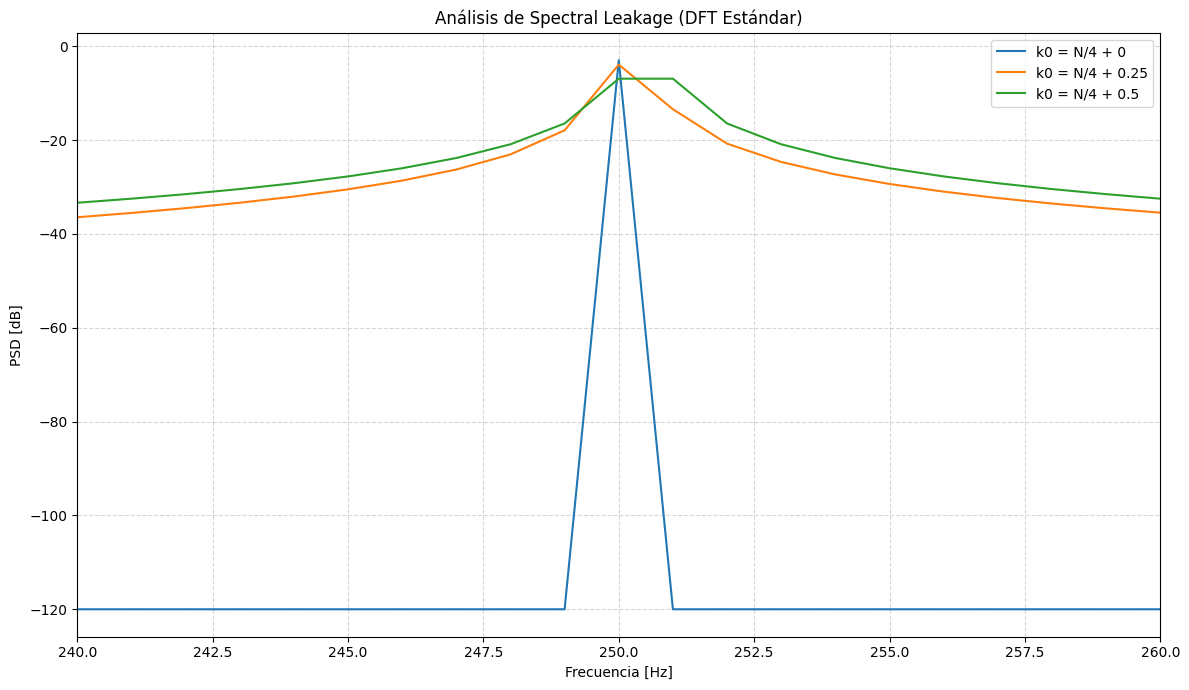

In [6]:
# Graficamos 
plt.figure(figsize=(12, 7))

# Analisis del desparramos espectral
for delta in desintonias:
    f0 = (N/4 + delta) * df
    
    tt, xx = MT_Senoidal(vmax=v_max, ff=f0, nn=N, fs=fs)
    
    dft_x = mi_funcion_DFT(xx)
    psd = (np.abs(dft_x)/N)**2
    
    freqs = np.linspace(0, fs, N, endpoint=False)
    
    potencia_total = np.sum(psd)
    print(f"Delta: {delta} -> Potencia total: {potencia_total:.4f}")

    mask = freqs >= 0
    plt.plot(freqs[mask], 10 * np.log10(psd[mask] + 1e-12), label=f'k0 = N/4 + {delta}')

# Graficamos 
plt.title('Análisis de Spectral Leakage (DFT Estándar)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.xlim([fs/4 - 10, fs/4 + 10]) 
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

## Discusión del espectro estándar y conservación de la energía

Al inspeccionar el gráfico en escala logarítmica (PSD en dB) centrado en la vecindad de Nyquist/2 ($250\text{ Hz}$), validamos experimentalmente las hipótesis planteadas:

* **Análisis de $\Delta = 0$ (Línea Azul):** Se observa una respuesta impulsional perfecta. Como la frecuencia es armónica a la ventana de observación, la DFT toma muestras exactamente en el vértice del lóbulo principal y en los cruces por cero de la Sinc. No existe desparramo visual.
  
* **Análisis de $\Delta = 0.5$ (Línea Verde):** Representa la peor condición de desintonía posible, donde la frecuencia real ($250.5\text{ Hz}$) cae exactamente a mitad de camino entre el bin 250 y el bin 251. Aquí se ve que la cresta del lóbulo principal no es capturada por ningún canal, provocando una pérdida de amplitud visible de aproximadamente $3.92\text{ dB}$. Toda esa energía remanente "gotea" y se redistribuye, elevando un piso de desparramo lateral que alcanza valores altos (cercanos a $-30\text{ dB}$ en las frecuencias vecinas).

## Teorema de Parseval (Discusión de Potencia)
A pesar de la deformación visual entre las curvas, las métricas impresas por consola demuestran la rigurosidad matemática del fenómeno:
* Potencia para $\Delta = 0 \rightarrow 1.0000$
* Potencia para $\Delta = 0.25 \rightarrow 0.9990$
* Potencia para $\Delta = 0.5 \rightarrow 1.0000$

La potencia total en el espectro se conserva unitaria y constante en los tres casos. Esto demuestra el **Teorema de Parseval**: la energía total de la senoidal en el tiempo ($V_{max}^2 / 2 = (\sqrt{2})^2 / 2 = 1$) es invariante. La desintonía no destruye energía ni genera nuevas señales físicas, simplemente provoca que la misma unidad de potencia, que antes estaba confinada en un único bin, se disperse a lo largo de todo el espectro de la DFT debido al acoplamiento de la ventana rectangular.

## 4. Bonus


Delta: 0 -> Potencia total: 10.0000
ZeroPad  - Delta: 0 -> Potencia total: 10.0000
Delta: 0.25 -> Potencia total: 9.9900
ZeroPad  - Delta: 0.25 -> Potencia total: 9.9900
Delta: 0.5 -> Potencia total: 10.0000
ZeroPad  - Delta: 0.5 -> Potencia total: 10.0000


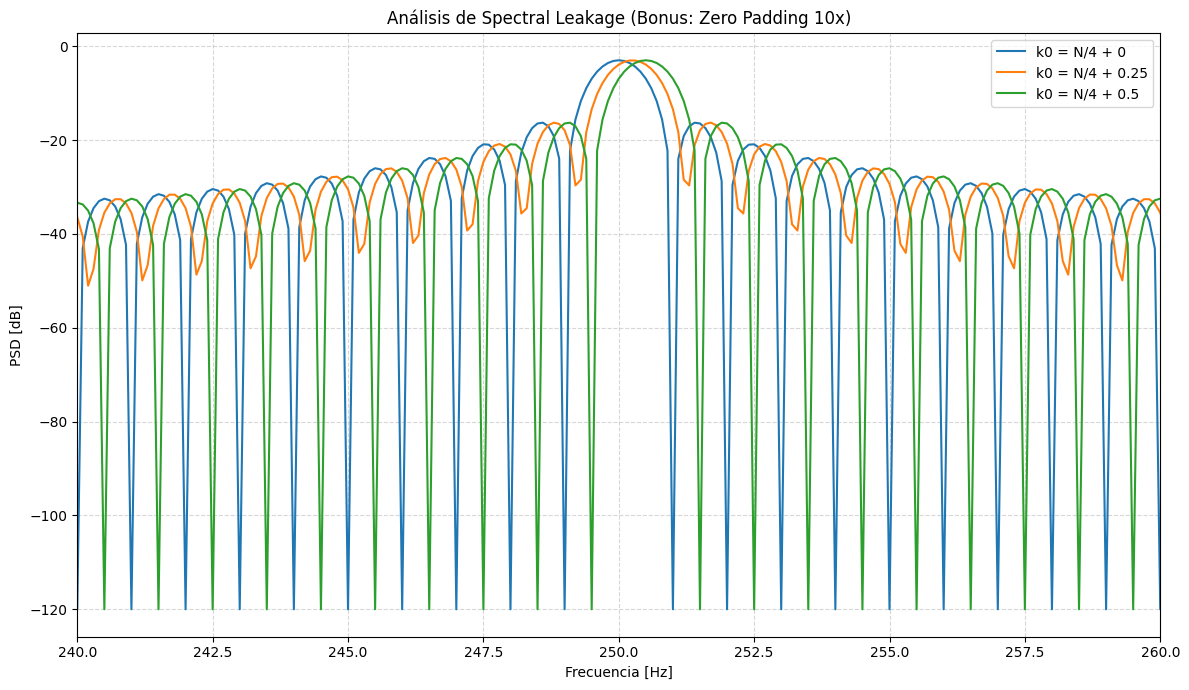

In [3]:
#%% Bonus 
plt.figure(figsize=(12, 7))

# Analisis espectral con Zero Padding
for delta in desintonias:
    f0 = (N/4 + delta) * df
    
    tt, xx = MT_Senoidal(vmax=v_max, ff=f0, nn=N, fs=fs)
    
    N_pad = 10 * N 
    
    dft_zero_padding = np.pad(xx, (0, 9*N), 'constant')
    
    dft_zero_padding = mi_funcion_DFT(dft_zero_padding)
    psd = (np.abs(dft_zero_padding) / N)**2 
    
    freqs = np.linspace(0, fs, len(dft_zero_padding), endpoint=False)
    
    potencia_total = np.sum(psd)
    print(f"Delta: {delta} -> Potencia total: {potencia_total:.4f}")

    mask = freqs >= 0
    print(f"ZeroPad  - Delta: {delta} -> Potencia total: {np.sum(psd):.4f}")

    mask = freqs <= fs/2
    plt.plot(freqs[mask], 10 * np.log10(psd[mask] + 1e-12), label=f'k0 = N/4 + {delta}')
    
# Graficamos 
plt.title('Análisis de Spectral Leakage (Bonus: Zero Padding 10x)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.xlim([fs/4 - 10, fs/4 + 10]) 
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Discusión Crítica del Zero Padding

En la segunda experiencia, se aplicó un *Zero Padding* de factor 10, extendiendo el vector con ceros hasta alcanzar $N_{pad} = 10000$ muestras.

* **Interpolación Espectral Ideal:** Es fundamental destacar que agregar ceros al final del registro temporal no agrega nueva información física del fenómeno ni mejora la resolución temporal del sistema. Lo que produce es un aumento en la densidad de muestras espectrales, reduciendo el espaciado entre bins a $\Delta f_{pad} = f_s / N_{pad} = 0.1\text{ Hz}$. Esto actúa como una interpolación ideal en el dominio de la frecuencia.

* **La Sinc Oculta:** Gracias a esta mayor densidad de puntos, el gráfico logarítmico revela con total nitidez el verdadero perfil de la ventana rectangular (el módulo de la función Sinc). 
    * Para $\Delta = 0$, la interpolación demuestra que la Sinc real siempre estuvo ahí, pero el muestreo de la DFT estándar justo coincidía con sus cruces por cero.
    * Para $\Delta = 0.5$, el gráfico revela el verdadero pico de la señal centrado de forma matemática en $250.5\text{ Hz}$, demostrando que el *Zero Padding* mitiga el error de medición de amplitud (*Picket-Fence Effect*) al permitirnos "ver" la verdadera cresta del lóbulo principal que antes caía en el vacío inter-bin.

## 5. Conclusiones Generales

1. Se concluye de forma práctica que la DFT finita no se comporta como un analizador espectral analógico ideal de resolución infinita, sino como filtros digitales en paralelo sintonizados a frecuencias discretas separadas por $\Delta f$.

2. Las señales analógicas bajo estudio son asincrónicas respecto al reloj de muestreo del ADC. Por ende, convivir con el *spectral leakage* es una condición por defecto en el procesamiento digital de señales.

3. El Zero Padding es una herramienta excelente para mejorar la precisión en la medición de frecuencias y amplitudes asincrónicas, actuando como un zoom que revela la morfología real de los lóbulos principales y secundarios. No obstante, el Zero Padding es incapaz de reducir la altura de los lóbulos secundarios (el desparramo lateral)